# 140kRealFakeFaces

In [28]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [29]:
output_dir = Path("final_performances_140k_realfake_plots")
output_dir.mkdir(parents=True, exist_ok=True)

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

rows = [
    {"model": "ResNet18", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.87954998, "loss": 0.346759021, "epoch_time_seconds": 5.99, "epochs": 34, "total_training_time_seconds": 203},
    {"model": "medium_cnn", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.506049991, "loss": 0.694786549, "epoch_time_seconds": 3.98, "epochs": 27, "total_training_time_seconds": 107},
    {"model": "ResNet18", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.97299999, "loss": 0.071945406, "epoch_time_seconds": 15.2, "epochs": 20, "total_training_time_seconds": 304},
    {"model": "medium_cnn", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.996299982, "loss": 0.01085264, "epoch_time_seconds": 198.73, "epochs": 102, "total_training_time_seconds": 20270},
    {"model": "small_cnn", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.824050009, "loss": 0.398396373, "epoch_time_seconds": 9.99, "epochs": 237, "total_training_time_seconds": 2368},
    {"model": "ResNet18", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.997049987, "loss": 0.009247121, "epoch_time_seconds": 124.08, "epochs": 18, "total_training_time_seconds": 2233},
    {"model": "medium_cnn", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.948400021, "loss": 0.176723748, "epoch_time_seconds": 21.16, "epochs": 109, "total_training_time_seconds": 2306},
    {"model": "small_cnn", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.5, "loss": 0.694532096, "epoch_time_seconds": 3.39, "epochs": 26, "total_training_time_seconds": 88},
    {"model": "small_cnn", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.916199982, "loss": 0.212135985, "epoch_time_seconds": 80.07, "epochs": 75, "total_training_time_seconds": 6025}
]

df = pd.DataFrame(rows)

df["total_training_time_min"] = df["total_training_time_seconds"] / 60

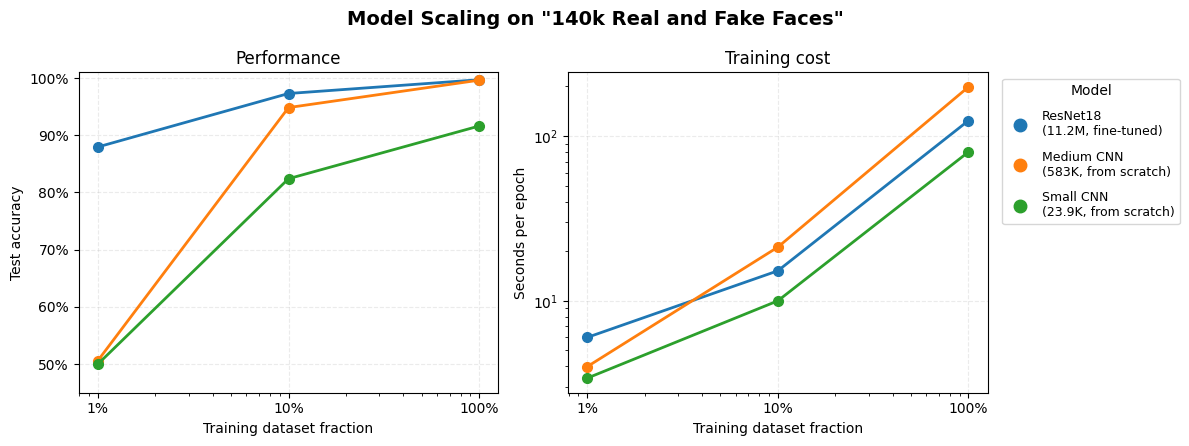

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.lines import Line2D

model_order = [
    "ResNet18",
    "medium_cnn",
    "small_cnn"
]

model_labels = {
    "ResNet18": "ResNet18\n(11.2M, fine-tuned)",
    "medium_cnn": "Medium CNN\n(583K, from scratch)",
    "small_cnn": "Small CNN\n(23.9K, from scratch)"
}

model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fig.suptitle(
    "Model Scaling on \"140k Real and Fake Faces\"",
    fontsize=14,
    fontweight="bold"
)

for model in model_order:

    subset = df[df["model"] == model]
    subset = subset.sort_values("dataset_fraction_value")

    axes[0].plot(
        subset["dataset_fraction_value"],
        subset["accuracy"],
        color=model_colors[model],
        marker="o",
        linewidth=2,
        markersize=7
    )

    axes[1].plot(
        subset["dataset_fraction_value"],
        subset["epoch_time_seconds"],
        color=model_colors[model],
        marker="o",
        linewidth=2,
        markersize=7
    )

# Accuracy plot
axes[0].set_xscale("log")
axes[0].set_xticks([1, 10, 100])
axes[0].set_xticklabels(["1%", "10%", "100%"])
axes[0].set_ylim(0.45, 1.01)

axes[0].set_xlabel("Training dataset fraction")
axes[0].set_ylabel("Test accuracy")
axes[0].set_title("Performance")

axes[0].yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0)
)

# Training time plot
axes[1].set_xscale("log")
axes[1].set_yscale("log")

axes[1].set_xticks([1, 10, 100])
axes[1].set_xticklabels(["1%", "10%", "100%"])

axes[1].set_xlabel("Training dataset fraction")
axes[1].set_ylabel("Seconds per epoch")
axes[1].set_title("Training cost")

# Common formatting
for axis in axes:

    axis.grid(
        alpha=0.25,
        linestyle="--"
    )

# Custom legend with colored circles
model_handles = []

for model in model_order:

    model_handles.append(
        Line2D(
            [0],
            [0],
            color=model_colors[model],
            marker="o",
            linestyle="None",
            markersize=9,
            label=model_labels[model]
        )
    )

axes[1].legend(
    handles=model_handles,
    title="Model",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9,
    title_fontsize=10,
    labelspacing=1.0
)

plt.tight_layout()
plt.show()

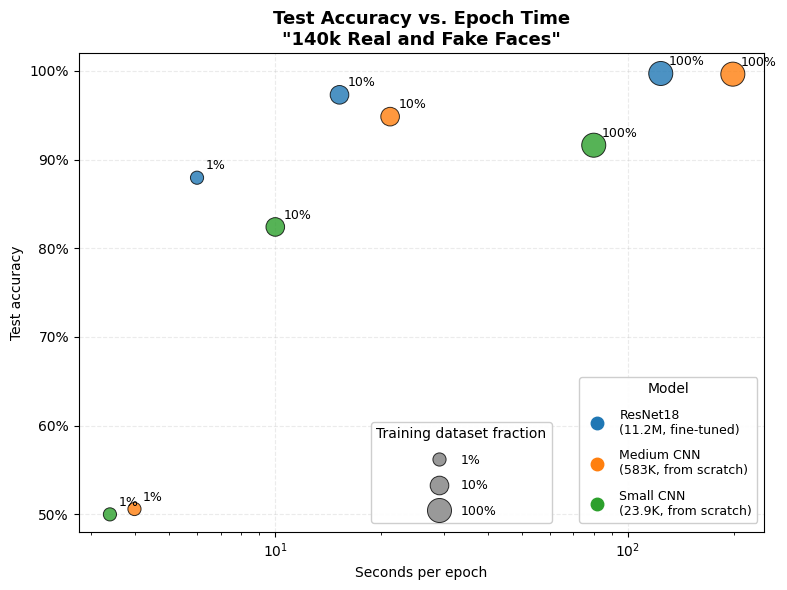

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.lines import Line2D

model_order = [
    "ResNet18",
    "medium_cnn",
    "small_cnn"
]

model_labels = {
    "ResNet18": "ResNet18\n(11.2M, fine-tuned)",
    "medium_cnn": "Medium CNN\n(583K, from scratch)",
    "small_cnn": "Small CNN\n(23.9K, from scratch)"
}

model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

marker_sizes = {
    1: 90,
    10: 180,
    100: 300
}

fig, ax = plt.subplots(
    figsize=(8, 6)
)

for model in model_order:

    subset = df[df["model"] == model]
    subset = subset.sort_values("dataset_fraction_value")

    sizes = []

    for fraction in subset["dataset_fraction_value"]:

        sizes.append(
            marker_sizes[fraction]
        )

    ax.scatter(
        subset["epoch_time_seconds"],
        subset["accuracy"],
        color=model_colors[model],
        s=sizes,
        alpha=0.8,
        edgecolor="black",
        linewidth=0.7
    )

    for _, row in subset.iterrows():

        annotation = row["dataset_fraction"]

        ax.annotate(
            annotation,
            xy=(
                row["epoch_time_seconds"],
                row["accuracy"]
            ),
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

ax.set_xscale("log")

ax.set_ylim(
    0.48,
    1.02
)

ax.set_xlabel(
    "Seconds per epoch"
)

ax.set_ylabel(
    "Test accuracy"
)

ax.set_title(
    'Test Accuracy vs. Epoch Time\n"140k Real and Fake Faces"',
    fontsize=13,
    fontweight="bold"
)

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0)
)

ax.grid(
    alpha=0.25,
    linestyle="--"
)

ax.set_axisbelow(
    True
)

# =========================
# MODEL LEGEND
# =========================

model_handles = []

for model in model_order:

    handle = Line2D(
        [0],
        [0],
        color=model_colors[model],
        marker="o",
        linestyle="None",
        markersize=9,
        label=model_labels[model]
    )

    model_handles.append(
        handle
    )

# =========================
# DATASET FRACTION LEGEND
# =========================

fraction_handles = []

for fraction in [1, 10, 100]:

    handle = Line2D(
        [0],
        [0],
        color="gray",
        marker="o",
        linestyle="None",
        markerfacecolor="gray",
        markeredgecolor="black",
        markeredgewidth=0.7,
        markersize=np.sqrt(marker_sizes[fraction]),
        alpha=0.8,
        label=f"{fraction}%"
    )

    fraction_handles.append(
        handle
    )

# Dataset-fraction legend on the left
fraction_legend = ax.legend(
    handles=fraction_handles,
    title="Training dataset fraction",
    loc="lower right",
    bbox_to_anchor=(0.69, 0.02),
    fontsize=9,
    title_fontsize=10,
    labelspacing=1.0,
    frameon=True,
    framealpha=0.95,
    borderaxespad=0
)

ax.add_artist(
    fraction_legend
)

# Model legend on the right
ax.legend(
    handles=model_handles,
    title="Model",
    loc="lower right",
    bbox_to_anchor=(0.99, 0.02),
    fontsize=9,
    title_fontsize=10,
    labelspacing=1.0,
    frameon=True,
    framealpha=0.95,
    borderaxespad=0
)

plt.tight_layout()
plt.show()

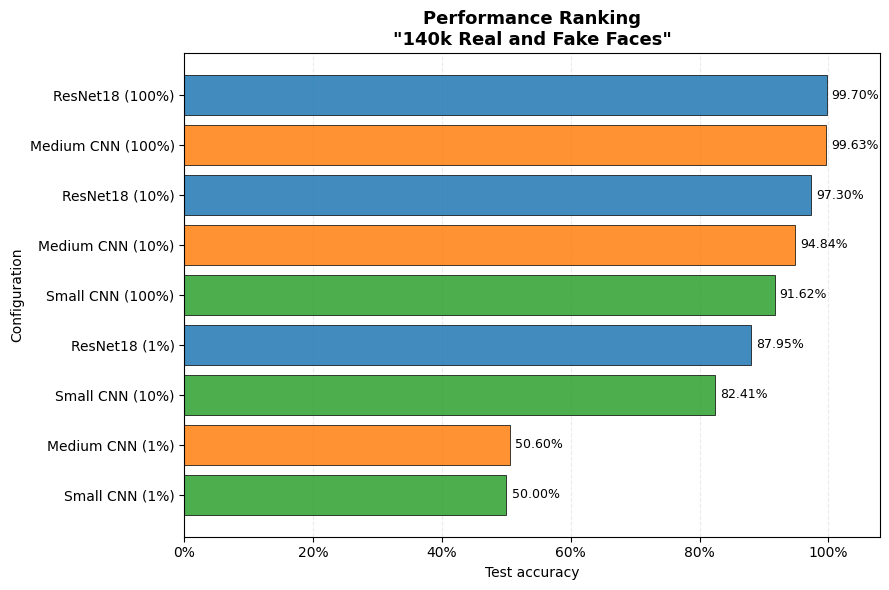

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create readable configuration names
df_bar = df.copy()

df_bar["configuration"] = (
    df_bar["model"]
    + " ("
    + df_bar["dataset_fraction"]
    + ")"
)

# Make model names consistent
df_bar["configuration"] = df_bar["configuration"].str.replace(
    "medium_cnn",
    "Medium CNN",
    regex=False
)

df_bar["configuration"] = df_bar["configuration"].str.replace(
    "small_cnn",
    "Small CNN",
    regex=False
)

# Sort configurations by decreasing accuracy
df_bar = df_bar.sort_values(
    "accuracy",
    ascending=False
).reset_index(drop=True)

# Keep the same color for each architecture
model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

colors = []

for model in df_bar["model"]:

    colors.append(
        model_colors[model]
    )

# Create plot
fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    df_bar["configuration"],
    df_bar["accuracy"],
    color=colors,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6
)

# Highest accuracy at the top
ax.invert_yaxis()

# Write accuracy next to each bar
for bar, accuracy in zip(bars, df_bar["accuracy"]):

    ax.text(
        accuracy + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy:.2%}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, 1.08)

ax.set_xlabel("Test accuracy")
ax.set_ylabel("Configuration")
ax.set_title(
    "Performance Ranking\n\"140k Real and Fake Faces\"",
    fontsize=13,
    fontweight="bold"
)
ax.xaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1.0)
)

ax.grid(
    axis="x",
    alpha=0.25,
    linestyle="--"
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

# FaceForensics++

In [41]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
rows = [
    {"task": "binary", "model": "ResNet18", "frames": 1, "f1_frame": 0.7420, "f1_video": 0.7922, "epoch_time_seconds": 6.19, "epochs": 32, "total_training_seconds": 198},
    {"task": "binary", "model": "ResNet18", "frames": 10, "f1_frame": 0.8188, "f1_video": 0.8396, "epoch_time_seconds": 37.91, "epochs": 27, "total_training_seconds": 1024},
    {"task": "binary", "model": "ResNet18", "frames": 100, "f1_frame": 0.8601, "f1_video": 0.8914, "epoch_time_seconds": 590.69, "epochs": 26, "total_training_seconds": 15358},
    {"task": "binary", "model": "medium_cnn", "frames": 1, "f1_frame": 0.4833, "f1_video": 0.4619, "epoch_time_seconds": 6.82, "epochs": 76, "total_training_seconds": 518},
    {"task": "binary", "model": "medium_cnn", "frames": 10, "f1_frame": 0.7353, "f1_video": 0.7699, "epoch_time_seconds": 59.96, "epochs": 56, "total_training_seconds": 3358},
    {"task": "binary", "model": "medium_cnn", "frames": 100, "f1_frame": 0.8125, "f1_video": 0.8458, "epoch_time_seconds": 651.38, "epochs": 34, "total_training_seconds": 22147},
    {"task": "binary", "model": "small_cnn", "frames": 1, "f1_frame": 0.4605, "f1_video": 0.4599, "epoch_time_seconds": 6.30, "epochs": 122, "total_training_seconds": 768},
    {"task": "binary", "model": "small_cnn", "frames": 10, "f1_frame": 0.5662, "f1_video": 0.5557, "epoch_time_seconds": 31.18, "epochs": 128, "total_training_seconds": 3991},
    {"task": "binary", "model": "small_cnn", "frames": 100, "f1_frame": 0.6432, "f1_video": 0.6494, "epoch_time_seconds": 522.19, "epochs": 44, "total_training_seconds": 22976},
    {"task": "multiclass", "model": "ResNet18", "frames": 1, "acc_frame": 0.8298, "f1_frame": 0.8302, "acc_video": 0.9119, "f1_video": 0.9126, "epoch_time_seconds": 5.40, "epochs": 31, "total_training_seconds": 167},
    {"task": "multiclass", "model": "ResNet18", "frames": 10, "acc_frame": 0.8595, "f1_frame": 0.8607, "acc_video": 0.9226, "f1_video": 0.9230, "epoch_time_seconds": 36.11, "epochs": 26, "total_training_seconds": 939},
    {"task": "multiclass", "model": "ResNet18", "frames": 100, "acc_frame": 0.9061, "f1_frame": 0.9067, "acc_video": 0.9488, "f1_video": 0.9489, "epoch_time_seconds": 580.73, "epochs": 26, "total_training_seconds": 15099},
    {"task": "multiclass", "model": "medium_cnn", "frames": 1, "acc_frame": 0.7752, "f1_frame": 0.7682, "acc_video": 0.8512, "f1_video": 0.8447, "epoch_time_seconds": 7.02, "epochs": 77, "total_training_seconds": 541},
    {"task": "multiclass", "model": "medium_cnn", "frames": 10, "acc_frame": 0.8488, "f1_frame": 0.8491, "acc_video": 0.9262, "f1_video": 0.9263, "epoch_time_seconds": 60.67, "epochs": 46, "total_training_seconds": 2791},
    {"task": "multiclass", "model": "medium_cnn", "frames": 100, "acc_frame": 0.9070, "f1_frame": 0.9074, "acc_video": 0.9512, "f1_video": 0.9513, "epoch_time_seconds": 644.25, "epochs": 34, "total_training_seconds": 21904},
    {"task": "multiclass", "model": "small_cnn", "frames": 1, "acc_frame": 0.4453, "f1_frame": 0.4147, "acc_video": 0.4583, "f1_video": 0.4269, "epoch_time_seconds": 4.66, "epochs": 229, "total_training_seconds": 1067},
    {"task": "multiclass", "model": "small_cnn", "frames": 10, "acc_frame": 0.7197, "f1_frame": 0.7207, "acc_video": 0.8071, "f1_video": 0.8072, "epoch_time_seconds": 30.79, "epochs": 166, "total_training_seconds": 5111},
    {"task": "multiclass", "model": "small_cnn", "frames": 100, "acc_frame": 0.8081, "f1_frame": 0.8062, "acc_video": 0.8940, "f1_video": 0.8930, "epoch_time_seconds": 436.33, "epochs": 135, "total_training_seconds": 58905}
]

df = pd.DataFrame(rows)
df = df.sort_values(["task", "model", "frames"]).reset_index(drop=True)
df["total_training_minutes"] = df["total_training_seconds"] / 60
df

,task,model,frames,f1_frame,f1_video,epoch_time_seconds,epochs,total_training_seconds,acc_frame,acc_video,total_training_minutes
0,binary,ResNet18,1,0.7420,0.7922,6.19,32,198,NaN,NaN,3.300000
1,binary,ResNet18,10,0.8188,0.8396,37.91,27,1024,NaN,NaN,17.066667
2,binary,ResNet18,100,0.8601,0.8914,590.69,26,15358,NaN,NaN,255.966667
3,binary,medium_cnn,1,0.4833,0.4619,6.82,76,518,NaN,NaN,8.633333
4,binary,medium_cnn,10,0.7353,0.7699,59.96,56,3358,NaN,NaN,55.966667
5,binary,medium_cnn,100,0.8125,0.8458,651.38,34,22147,NaN,NaN,369.116667
6,binary,small_cnn,1,0.4605,0.4599,6.30,122,768,NaN,NaN,12.800000
7,binary,small_cnn,10,0.5662,0.5557,31.18,128,3991,NaN,NaN,66.516667
8,binary,small_cnn,100,0.6432,0.6494,522.19,44,22976,NaN,NaN,382.933333
9,multiclass,ResNet18,1,0.8302,0.9126,5.40,31,167,0.8298,0.9119,2.783333


In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.lines import Line2D

model_order = [
    "ResNet18",
    "medium_cnn",
    "small_cnn"
]

model_labels = {
    "ResNet18": "ResNet18\n(11.2M, fine-tuned)",
    "medium_cnn": "Medium CNN\n(583K, from scratch)",
    "small_cnn": "Small CNN\n(23.9K, from scratch)"
}

model_short_labels = {
    "ResNet18": "ResNet18",
    "medium_cnn": "Medium CNN",
    "small_cnn": "Small CNN"
}

model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

task_order = [
    "binary",
    "multiclass"
]

task_labels = {
    "binary": "Binary Classification",
    "multiclass": "Multiclass Classification"
}

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_order = [
    "ResNet18",
    "medium_cnn",
    "small_cnn"
]

model_labels = {
    "ResNet18": "ResNet18\n(11.2M)",
    "medium_cnn": "Medium CNN\n(583K)",
    "small_cnn": "Small CNN\n(23.9K)"
}

model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

task_titles = {
    "binary": "Binary Classification",
    "multiclass": "Multiclass Classification"
}

def plot_task_scaling(df, task):

    task_df = df[df["task"] == task].copy()

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(15, 5.4)
    )

    ax_perf = axes[0]
    ax_cost = axes[1]

    # =========================
    # LEFT: PERFORMANCE SCALING
    # =========================

    for model in model_order:

        subset = task_df[task_df["model"] == model]
        subset = subset.sort_values("frames")

        ax_perf.plot(
            subset["frames"],
            subset["f1_frame"],
            color=model_colors[model],
            marker="s",
            linestyle="--",
            linewidth=2,
            markersize=6,
            alpha=0.85
        )

        ax_perf.plot(
            subset["frames"],
            subset["f1_video"],
            color=model_colors[model],
            marker="o",
            linestyle="-",
            linewidth=2,
            markersize=7
        )

    ax_perf.set_xscale("log")
    ax_perf.set_xticks([1, 10, 100])
    ax_perf.set_xticklabels(["1", "10", "100"])

    if task == "binary":
        ax_perf.set_ylim(0.40, 0.93)
    else:
        ax_perf.set_ylim(0.40, 0.98)

    ax_perf.set_xlabel("Frames extracted per video")
    ax_perf.set_ylabel("Test F1-score")
    ax_perf.set_title("Performance")
    ax_perf.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

    ax_perf.grid(
        alpha=0.25,
        linestyle="--"
    )

    # =========================
    # RIGHT: TRAINING COST
    # =========================

    for model in model_order:

        subset = task_df[task_df["model"] == model]
        subset = subset.sort_values("frames")

        ax_cost.plot(
            subset["frames"],
            subset["epoch_time_seconds"],
            color=model_colors[model],
            marker="o",
            linestyle="-",
            linewidth=2,
            markersize=7
        )

    ax_cost.set_xscale("log")
    ax_cost.set_yscale("log")

    ax_cost.set_xticks([1, 10, 100])
    ax_cost.set_xticklabels(["1", "10", "100"])

    ax_cost.set_xlabel("Frames extracted per video")
    ax_cost.set_ylabel("Seconds per epoch")
    ax_cost.set_title("Training cost")

    ax_cost.grid(
        alpha=0.25,
        linestyle="--"
    )

    # =========================
    # LEGENDS
    # =========================

    model_handles = []

    for model in model_order:

        model_handles.append(
            Line2D(
                [0],
                [0],
                color=model_colors[model],
                marker="o",
                linestyle="None",
                markersize=9,
                label=model_labels[model]
            )
        )

    evaluation_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            marker="s",
            linewidth=2,
            markersize=6,
            label="Frame-level F1"
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-",
            marker="o",
            linewidth=2,
            markersize=7,
            label="Video-level F1"
        )
    ]

    model_legend = ax_cost.legend(
        handles=model_handles,
        title="Model",
        bbox_to_anchor=(1.02, 1.0),
        loc="upper left",
        fontsize=10,
        title_fontsize=11,
        labelspacing=1.0
    )

    ax_cost.add_artist(model_legend)

    ax_cost.legend(
        handles=evaluation_handles,
        title="Evaluation",
        bbox_to_anchor=(1.02, 0.46),
        loc="upper left",
        fontsize=10,
        title_fontsize=11,
        labelspacing=0.8
    )

    fig.tight_layout(
        rect=[0, 0, 0.82, 0.91]
    )

    # Get the horizontal limits of the two plot area
    plots_left = ax_perf.get_position().x0
    plots_right = ax_cost.get_position().x1

    # Compute the center of the two plot area
    title_x = (
        plots_left
        + plots_right
    ) / 2

    # Center the title over the plots, excluding the legends
    fig.suptitle(
        f'Model Scaling on "FaceForensics++" ({task_titles[task]})',
        x=title_x,
        y=0.97,
        fontsize=16,
        fontweight="bold"
    )

    plt.show()

    plt.show()

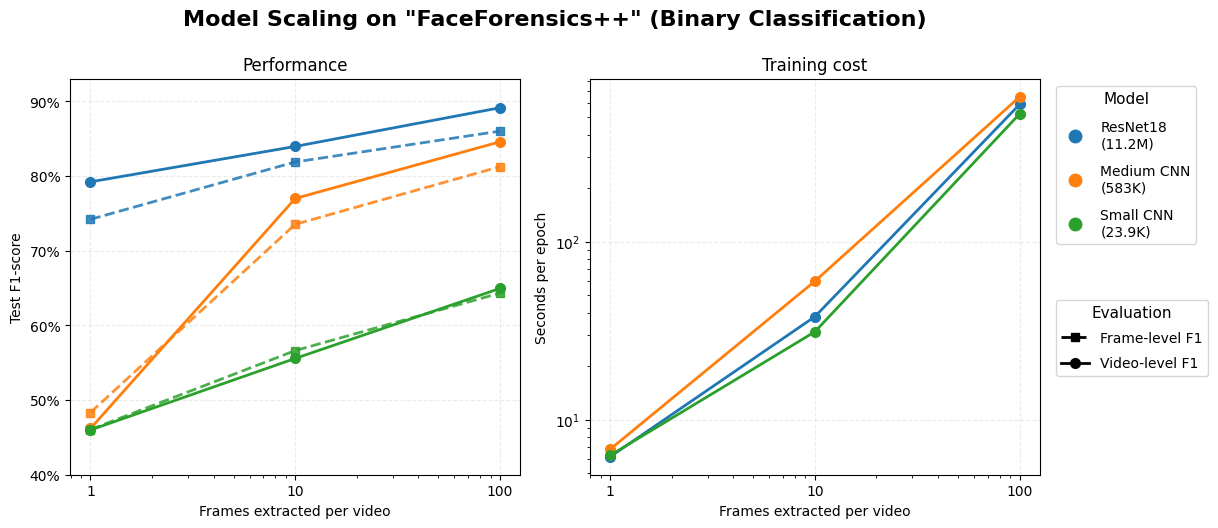

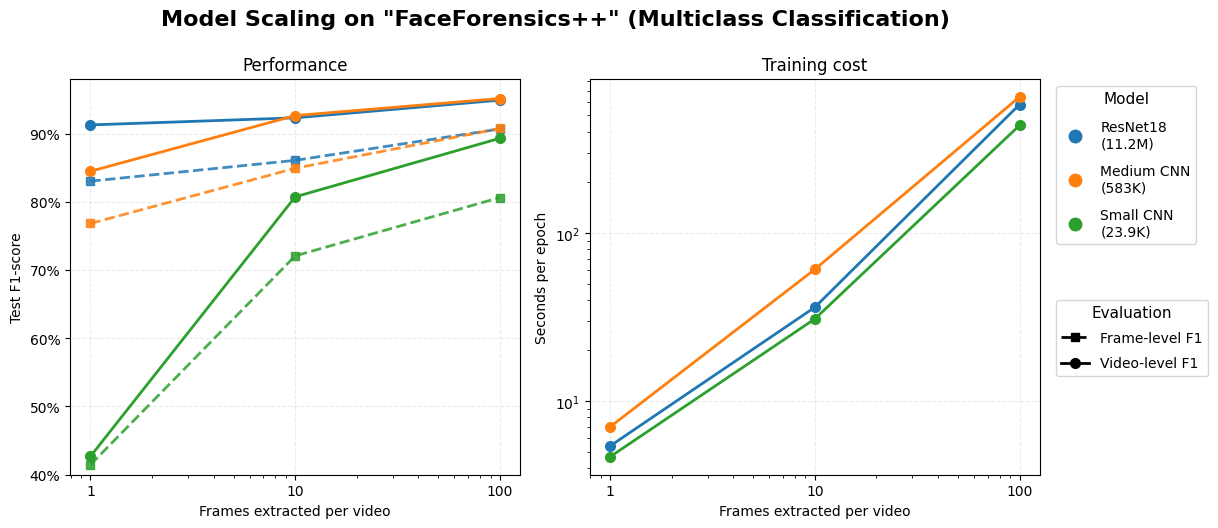

In [45]:
plot_task_scaling(df, "binary")
plot_task_scaling(df, "multiclass")

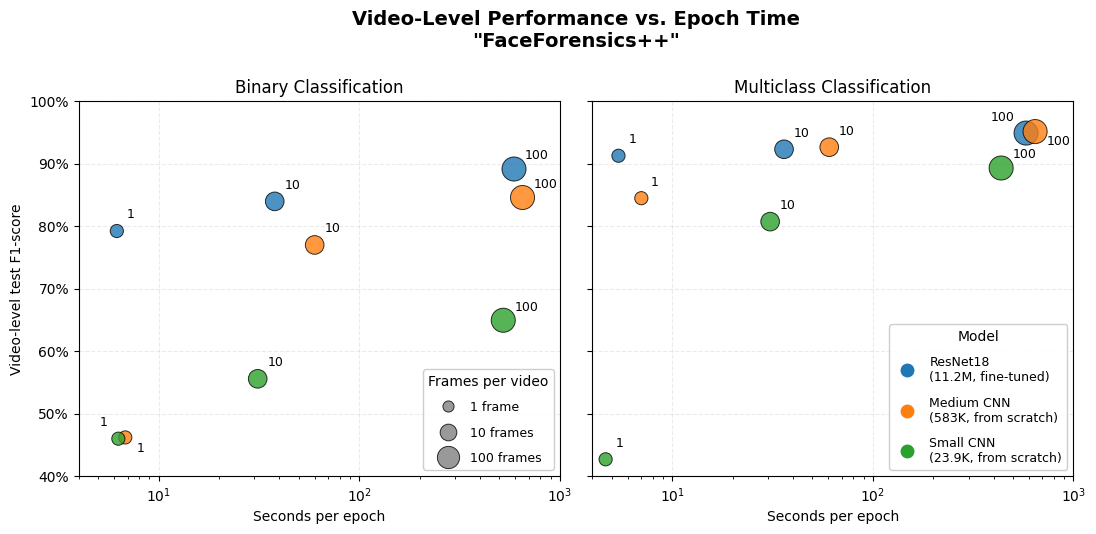

In [46]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from matplotlib.lines import Line2D


def plot_video_performance_vs_epoch_time(df):

    model_order = [
        "ResNet18",
        "medium_cnn",
        "small_cnn"
    ]

    model_labels = {
    "ResNet18": "ResNet18\n(11.2M, fine-tuned)",
    "medium_cnn": "Medium CNN\n(583K, from scratch)",
    "small_cnn": "Small CNN\n(23.9K, from scratch)"
    }

    model_colors = {
        "ResNet18": "tab:blue",
        "medium_cnn": "tab:orange",
        "small_cnn": "tab:green"
    }

    task_order = [
        "binary",
        "multiclass"
    ]

    task_labels = {
        "binary": "Binary Classification",
        "multiclass": "Multiclass Classification"
    }

    # Marker areas used inside the plots
    marker_sizes = {
        1: 90,
        10: 180,
        100: 300
    }

    # Marker diameters used only inside the legend
    frame_legend_sizes = {
        1: 8,
        10: 12,
        100: 16
    }

    # Custom offsets used to separate overlapping annotations
    annotation_offsets = {
        ("binary", "ResNet18", 1): (7, 7),
        ("binary", "ResNet18", 10): (7, 7),
        ("binary", "ResNet18", 100): (8, 5),

        ("binary", "medium_cnn", 1): (8, -3),
        ("binary", "medium_cnn", 10): (7, 7),
        ("binary", "medium_cnn", 100): (8, 5),

        ("binary", "small_cnn", 1): (-8, 7),
        ("binary", "small_cnn", 10): (7, 7),
        ("binary", "small_cnn", 100): (8, 5),

        ("multiclass", "ResNet18", 1): (7, 7),
        ("multiclass", "ResNet18", 10): (7, 7),
        ("multiclass", "ResNet18", 100): (-8, 7),

        ("multiclass", "medium_cnn", 1): (7, 7),
        ("multiclass", "medium_cnn", 10): (7, 7),
        ("multiclass", "medium_cnn", 100): (8, -2),

        ("multiclass", "small_cnn", 1): (7, 7),
        ("multiclass", "small_cnn", 10): (7, 7),
        ("multiclass", "small_cnn", 100): (8, 5)
    }

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5.4),
        sharey=True
    )

    # =========================
    # CREATE THE TWO PANELS
    # =========================

    for axis, task in zip(axes, task_order):

        task_df = df[df["task"] == task].copy()

        for model in model_order:

            subset = task_df[task_df["model"] == model]
            subset = subset.sort_values("frames")

            sizes = []

            for frames in subset["frames"]:

                frames = int(frames)

                sizes.append(
                    marker_sizes[frames]
                )

            axis.scatter(
                subset["epoch_time_seconds"],
                subset["f1_video"],
                color=model_colors[model],
                s=sizes,
                alpha=0.8,
                edgecolor="black",
                linewidth=0.7
            )

            # Add the number of frames next to every point
            for _, row in subset.iterrows():

                frames = int(row["frames"])

                offset = annotation_offsets.get(
                    (task, model, frames),
                    (7, 7)
                )

                horizontal_alignment = "left"

                if offset[0] < 0:

                    horizontal_alignment = "right"

                vertical_alignment = "bottom"

                if offset[1] < 0:

                    vertical_alignment = "top"

                axis.annotate(
                    str(frames),
                    xy=(
                        row["epoch_time_seconds"],
                        row["f1_video"]
                    ),
                    xytext=offset,
                    textcoords="offset points",
                    fontsize=9,
                    horizontalalignment=horizontal_alignment,
                    verticalalignment=vertical_alignment
                )

        axis.set_xscale("log")

        axes[0].set_xlim(4, 1000)
        axes[1].set_xlim(4, 1000)
        

        axis.set_ylim(
            0.40,
            1
        )

        axis.set_xlabel(
            "Seconds per epoch"
        )

        axis.set_title(
            task_labels[task]
        )

        axis.yaxis.set_major_formatter(
            mtick.PercentFormatter(xmax=1.0)
        )

        axis.grid(
            alpha=0.25,
            linestyle="--"
        )

        axis.set_axisbelow(
            True
        )

    axes[0].set_ylabel(
        "Video-level test F1-score"
    )

    # =========================
    # MODEL LEGEND
    # =========================

    model_handles = []

    for model in model_order:

        handle = Line2D(
            [0],
            [0],
            color=model_colors[model],
            marker="o",
            linestyle="None",
            markersize=9,
            label=model_labels[model]
        )

        model_handles.append(
            handle
        )

    # =========================
    # FRAME NUMBER LEGEND
    # =========================

    frame_handles = []

    for frames in [1, 10, 100]:

        label = f"{frames} frames"

        if frames == 1:

            label = "1 frame"

        handle = Line2D(
            [0],
            [0],
            color="gray",
            marker="o",
            linestyle="None",
            markerfacecolor="gray",
            markeredgecolor="black",
            markeredgewidth=0.7,
            markersize=frame_legend_sizes[frames],
            alpha=0.8,
            label=label
        )

        frame_handles.append(
            handle
        )

    # Frames legend inside the binary-classification subplot
    axes[0].legend(
        handles=frame_handles,
        title="Frames per video",
        loc="lower right",
        fontsize=9,
        title_fontsize=10,
        labelspacing=1.0,
        frameon=True,
        framealpha=0.95
    )

    # Model legend inside the multiclass-classification subplot
    axes[1].legend(
        handles=model_handles,
        title="Model",
        loc="lower right",
        fontsize=9,
        title_fontsize=10,
        labelspacing=1.0,
        frameon=True,
        framealpha=0.95
    )

    # Reserve space for external legends and title
    fig.tight_layout(
        rect=[0, 0, 0.79, 0.88]
    )

    # Find the horizontal center of the two plot panels
    plots_left = axes[0].get_position().x0
    plots_right = axes[1].get_position().x1

    title_x = (
        plots_left
        + plots_right
    ) / 2

    # Center the title over the two panels
    fig.suptitle(
        'Video-Level Performance vs. Epoch Time\n"FaceForensics++"',
        x=title_x,
        y=0.98,
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

plot_video_performance_vs_epoch_time(df)

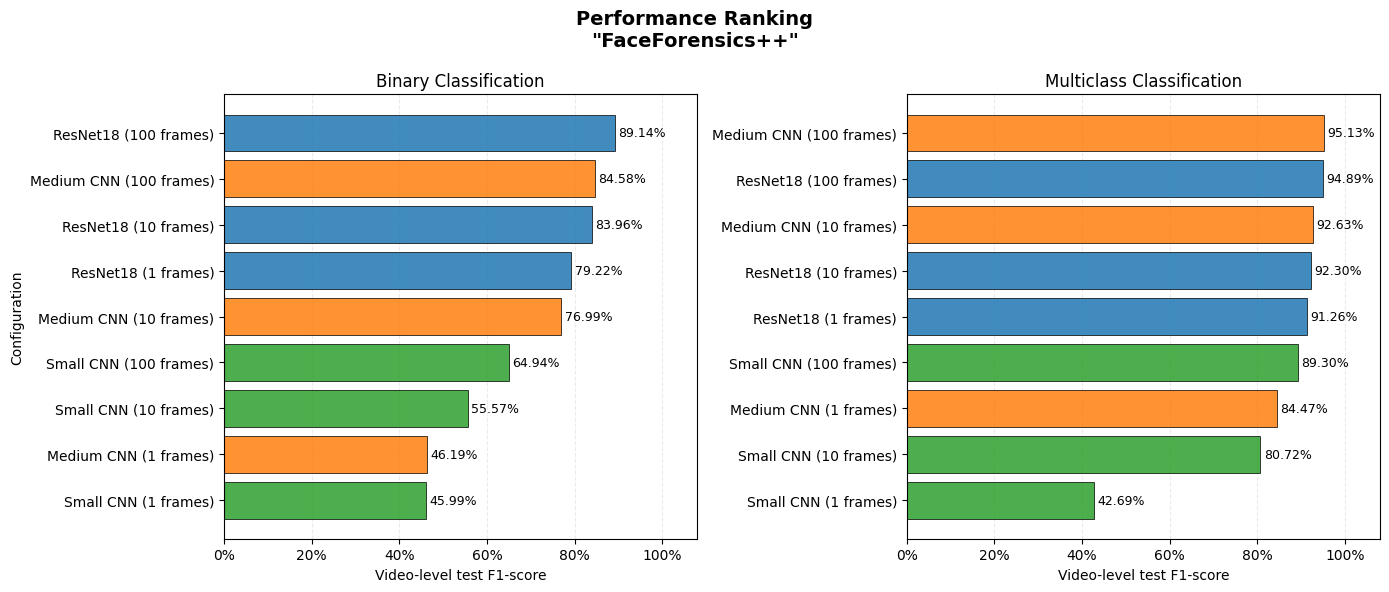

In [47]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

model_order = [
    "ResNet18",
    "medium_cnn",
    "small_cnn"
]

model_colors = {
    "ResNet18": "tab:blue",
    "medium_cnn": "tab:orange",
    "small_cnn": "tab:green"
}

task_order = [
    "binary",
    "multiclass"
]

task_titles = {
    "binary": "Binary Classification",
    "multiclass": "Multiclass Classification"
}

def plot_ffpp_performance_ranking(df):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
        sharex=True
    )

    for axis, task in zip(axes, task_order):

        task_df = df[df["task"] == task].copy()

        task_df["configuration"] = (
            task_df["model"]
            + " ("
            + task_df["frames"].astype(str)
            + " frames)"
        )

        task_df["configuration"] = task_df["configuration"].str.replace(
            "medium_cnn",
            "Medium CNN",
            regex=False
        )

        task_df["configuration"] = task_df["configuration"].str.replace(
            "small_cnn",
            "Small CNN",
            regex=False
        )

        task_df = task_df.sort_values(
            "f1_video",
            ascending=False
        ).reset_index(drop=True)

        colors = []

        for model in task_df["model"]:
            colors.append(
                model_colors[model]
            )

        bars = axis.barh(
            task_df["configuration"],
            task_df["f1_video"],
            color=colors,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.6
        )

        axis.invert_yaxis()

        for bar, score in zip(bars, task_df["f1_video"]):

            axis.text(
                score + 0.008,
                bar.get_y() + bar.get_height() / 2,
                f"{score:.2%}",
                va="center",
                fontsize=9
            )

        axis.set_xlim(
            0,
            1.08
        )

        axis.set_title(
            task_titles[task]
        )

        axis.xaxis.set_major_formatter(
            mtick.PercentFormatter(xmax=1.0)
        )

        axis.grid(
            axis="x",
            alpha=0.25,
            linestyle="--"
        )

        axis.set_axisbelow(
            True
        )

    axes[0].set_xlabel("Video-level test F1-score")
    axes[1].set_xlabel("Video-level test F1-score")

    axes[0].set_ylabel("Configuration")
    axes[1].set_ylabel("")

    fig.tight_layout(
        rect=[0, 0, 1, 0.90]
    )

    fig.suptitle(
        'Performance Ranking\n"FaceForensics++"',
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

plot_ffpp_performance_ranking(df)